In [22]:
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import learning_curve, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, VotingRegressor

In [5]:
# Load and sort data chronologically
df = pd.read_csv('Integrated Dataset_bhavyaVerma.csv')
df['DateTime']= df['Date'] + ' ' + df['TimeStamp']
df['DateTime'] = pd.to_datetime(df['DateTime'], format= "%Y-%m-%d %H:%M:%S")
df = df.sort_values('DateTime')

# Feature Engineering for regression models
df['Hour'] = df['DateTime'].dt.hour
df['Day'] = df['DateTime'].dt.dayofweek
df['Lag_1'] = df.groupby('Junction')['Vehicles'].shift(1)
df = df.dropna()

# --- Time-Based Split ---
# We use the first 80% of time for training, the last 20% for testing
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

X_cols = ['Hour', 'Day', 'Lag_1', 'Rain', 'Temp Max']
y_col = 'Vehicles'

X_train, y_train = train[X_cols], train[y_col]
X_test, y_test = test[X_cols], test[y_col]

In [6]:
# Setup Time-Series Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

# Hyperparameter grid
param_dist = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10]
}

gbr = GradientBoostingRegressor(random_state=42)
random_search = RandomizedSearchCV(gbr, param_distributions=param_dist, 
                                   n_iter=10, cv=tscv, scoring='neg_mean_absolute_error')

random_search.fit(X_train, y_train)
print(f"Best Configuration: {random_search.best_params_}")

Best Configuration: {'n_estimators': 100, 'min_samples_split': 10, 'max_depth': 3, 'learning_rate': 0.1}


In [15]:
# 1. Filter for your specific Junction
j1_data = df[df['Junction'] == 1].copy()

# 2. Set DateTime as the Index (Crucial for ARIMA)
j1_data = j1_data.set_index('DateTime')

# 3. Ensure a consistent Hourly frequency
# This identifies if any hours are missing in your raw data
j1_data = j1_data.asfreq('h')

# 4. Fill gaps (If an hour was missing, it now has a NaN)
# ARIMA cannot handle NaNs. We 'Forward Fill' the previous hour's value.
j1_data['Vehicles'] = j1_data['Vehicles'].ffill()

# 5. Define the series
j1_series = j1_data['Vehicles']

# 6. Fit the model
try:
    arima_model = ARIMA(j1_series, order=(1, 1, 1))
    arima_result = arima_model.fit()
    print("Model fitted successfully!")
except Exception as e:
    print(f"Error: {e}")

Model fitted successfully!


In [18]:
# Scaling data for LSTM
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train[['Vehicles'] + X_cols])

def create_sequences(data, seq_length=24):
    xs, ys = [], []
    for i in range(len(data)-seq_length):
        xs.append(data[i:(i+seq_length)]) # Past 24 hours features
        ys.append(data[i+seq_length, 0]) # Current hour vehicle count
    return np.array(xs), np.array(ys)

X_train_lstm, y_train_lstm = create_sequences(scaled_train)
# X_train_lstm.shape will be (N, 24, 6)

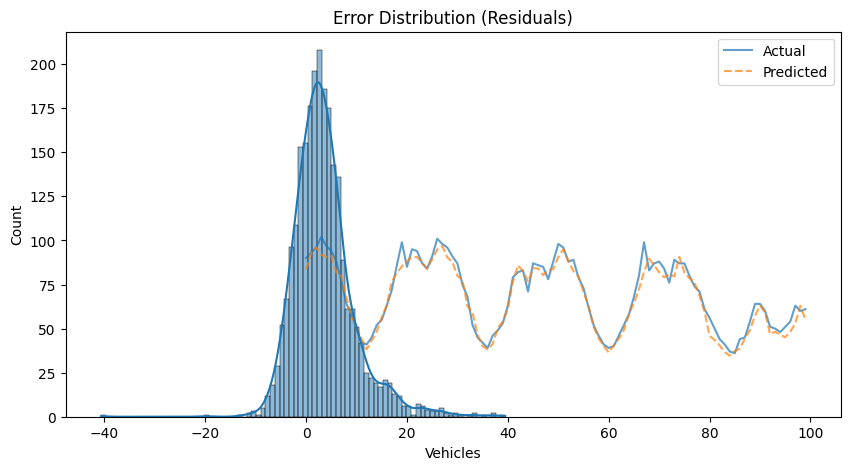

In [21]:
# 1. Setup Time-Series Cross-Validation
# We use 5 folds. The model trains on Fold 1 to predict Fold 2, then trains on Folds 1-2 to predict Fold 3, etc.
tscv = TimeSeriesSplit(n_splits=5)
cv_results = []

# Prepare features and target for Junction 1
X = j1_data[['Hour', 'Day', 'Lag_1', 'Rain', 'Temp Max']]
y = j1_data['Vehicles']

# 2. Implement Cross-Validation Loop
for train_index, val_index in tscv.split(X):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    # Train the chosen model
    model = GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
    model.fit(X_train, y_train)
    
    # Evaluate
    y_pred = model.predict(X_val)
    cv_results.append({
        'MAE': mean_absolute_error(y_val, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_val, y_pred)),
        'R2': r2_score(y_val, y_pred)
    })

# 3. Visualizing Model Performance (Final Fold Example)
plt.figure(figsize=(10, 5))
plt.plot(y_val.values[:100], label='Actual', alpha=0.7)
plt.plot(y_pred[:100], label='Predicted', alpha=0.7, linestyle='--')
plt.title('Prediction vs Actual (Traffic Volume)')
plt.legend()
plt.savefig('actual_vs_predicted.png')

# 4. Residual Analysis
residuals = y_val - y_pred
sns.histplot(residuals, kde=True)
plt.title('Error Distribution (Residuals)')
plt.savefig('error_distribution.png')

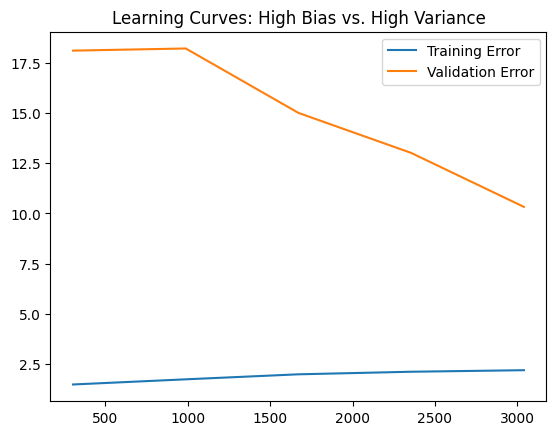

In [24]:
# 1. Diagnose Model Issues (Learning Curves)
# This helps identify if we need more data or more complex features
train_sizes, train_scores, test_scores = learning_curve(
    GradientBoostingRegressor(), X_train, y_train, 
    cv=TimeSeriesSplit(n_splits=3), scoring='neg_mean_absolute_error'
)

# Plotting the curve
plt.plot(train_sizes, -np.mean(train_scores, axis=1), label='Training Error')
plt.plot(train_sizes, -np.mean(test_scores, axis=1), label='Validation Error')
plt.title('Learning Curves: High Bias vs. High Variance')
plt.legend()
plt.savefig('learning_curves.png')



In [27]:
# 2. Error Analysis (Identifying Systematic Weakness)
# We check if the model consistently fails during specific hours

# 1. Define the model with the name 'base_model'
base_model = GradientBoostingRegressor(n_estimators=100, random_state=42)

# 2. Train (fit) the model
base_model.fit(X_train, y_train)

# 3. Now you can use it to predict and calculate residuals
y_pred = base_model.predict(X_test)
residuals = y_test - y_pred

print("Success! base_model is now defined and residuals are calculated.")
# residuals = y_test - base_model.predict(X_test)
error_by_hour = pd.DataFrame({'Hour': X_test['Hour'], 'Error': residuals}).groupby('Hour').mean()

# 3. Improve Model (Ensemble Architecture)
# We combine Gradient Boosting (low bias) with Random Forest (low variance)
model_gb = GradientBoostingRegressor(n_estimators=100, max_depth=5)
model_rf = RandomForestRegressor(n_estimators=100, max_depth=5)

ensemble = VotingRegressor([('gb', model_gb), ('rf', model_rf)])
ensemble.fit(X_train, y_train)

Success! base_model is now defined and residuals are calculated.


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('gb', ...), ('rf', ...)]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1


In [28]:
# 4. Final Refinement (Grid Search)
param_grid = {
    'gb__learning_rate': [0.01, 0.05, 0.1],
    'gb__n_estimators': [100, 200]
}
grid_search = GridSearchCV(ensemble, param_grid, cv=TimeSeriesSplit(n_splits=3))
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",VotingRegress...ax_depth=5))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'gb__learning_rate': [0.01, 0.05, ...], 'gb__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displa